# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [3]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [4]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

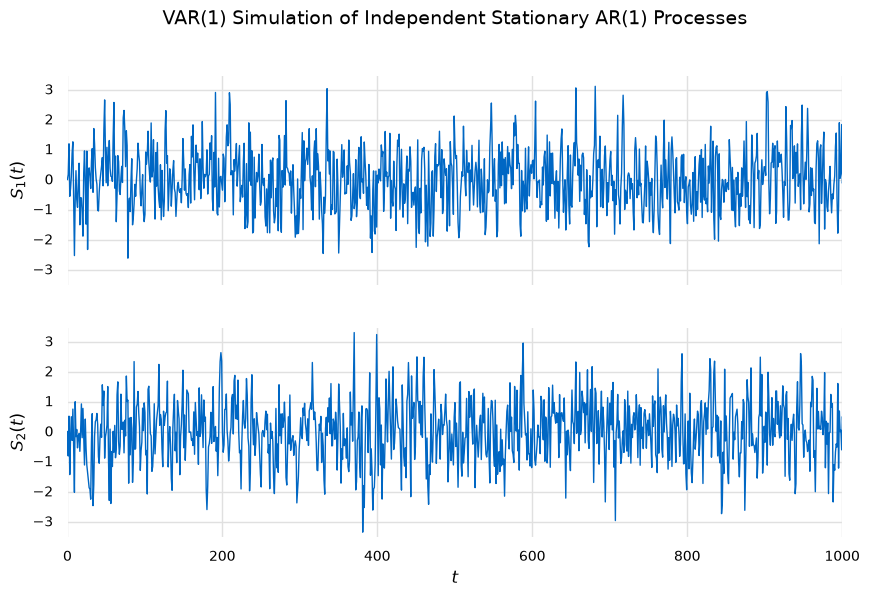

In [5]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [6]:
result, result_model = var.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1075,0.1101,1.113,0.1084
1,-0.02659*,-0.01877*,0.9738*,-0.02385*
2,-0.02615,-0.01311,0.9742,-0.02158
3,-0.02498,-0.006716,0.9753,-0.01858
4,-0.02437,-0.0008918,0.9759,-0.01614


In [7]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
   "_VAROrderTestReport__order": {
      "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
      "order": {
         "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.026593228633130128
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
      "order": {
         "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "3b74c7b0-8c6a-4499-af34-fcde0acf6097",
      

In [8]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0188197
Nobs:                     4999.00    HQIC:                -0.0239002
Log likelihood:          -14114.0    FPE:                   0.973710
AIC:                   -0.0266417    Det(Omega_mle):        0.972542
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.001384         0.013889           -0.100           0.921
L1.y1         0.251230         0.013700           18.338           0.000
L1.y2        -0.021764         0.013358           -1.629           0.103

Results for equation 

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.0013835119226805789,
         "err": 0.013888634240785154,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "f8bdcd7b-4097-4f2f-98d9-dd8d73e31003",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.007591651094991994,
         "err": 0.014205432825398797,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "f8bdcd7b-4097-4f2f-98d9-dd8d73e31003",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 1,
   "params": [
      {
         "est": 0.2512304419729862,
         "err": 0.013699695446825684,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "f8bdcd7b-4097-4f2f-98d9-dd8d73e310

### Coupled $\text{AR}(1)$

In [10]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [11]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

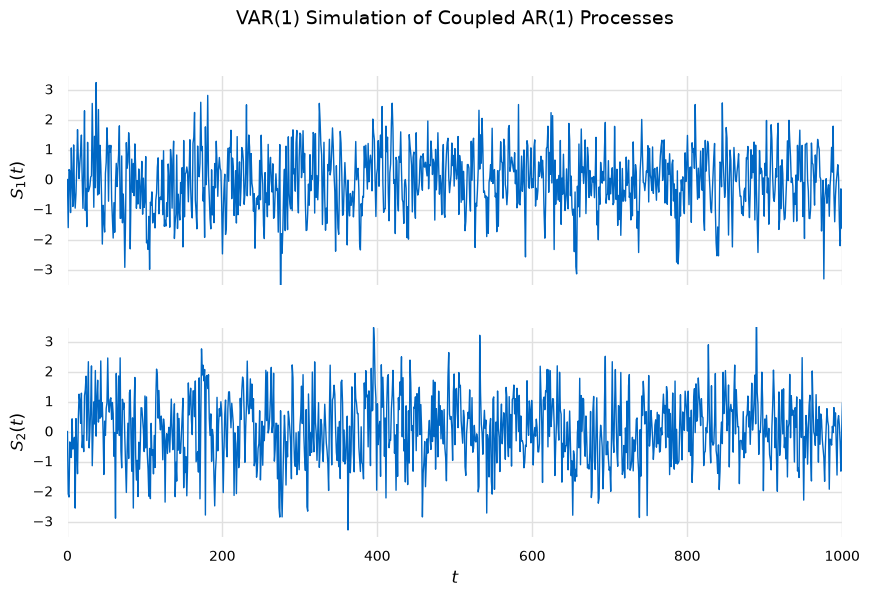

In [12]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [13]:
result, result_model = var.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3110,0.3137,1.365,0.3120
1,-0.007622*,0.0002036*,0.9924*,-0.004879*
2,-0.006943,0.006100,0.9931,-0.002371
3,-0.007246,0.01101,0.9928,-0.0008457
4,-0.006510,0.01697,0.9935,0.001719


In [14]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
   "_VAROrderTestReport__order": {
      "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
      "order": {
         "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.007622313030748887
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
      "order": {
         "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "d53c4ab2-b05b-4fca-b819-42edde74dc8f",
      

In [15]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                0.000835797
Nobs:                     4999.00    HQIC:               -0.00424466
Log likelihood:          -14163.1    FPE:                   0.993038
AIC:                  -0.00698616    Det(Omega_mle):        0.991847
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.005002         0.014043            0.356           0.722
L1.y1         0.261706         0.013726           19.067           0.000
L1.y2         0.054818         0.012398            4.421           0.000

Results for equation 

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": 0.00500187345162045,
         "err": 0.014042700263793168,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "bc30d2e7-0098-4315-a297-b623b0ca51a4",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.031378287595390866,
         "err": 0.014206874351871516,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "bc30d2e7-0098-4315-a297-b623b0ca51a4",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 1,
   "params": [
      {
         "est": 0.26170550530145803,
         "err": 0.01372585333442267,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "bc30d2e7-0098-4315-a297-b623b0ca51a4",

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [17]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [18]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

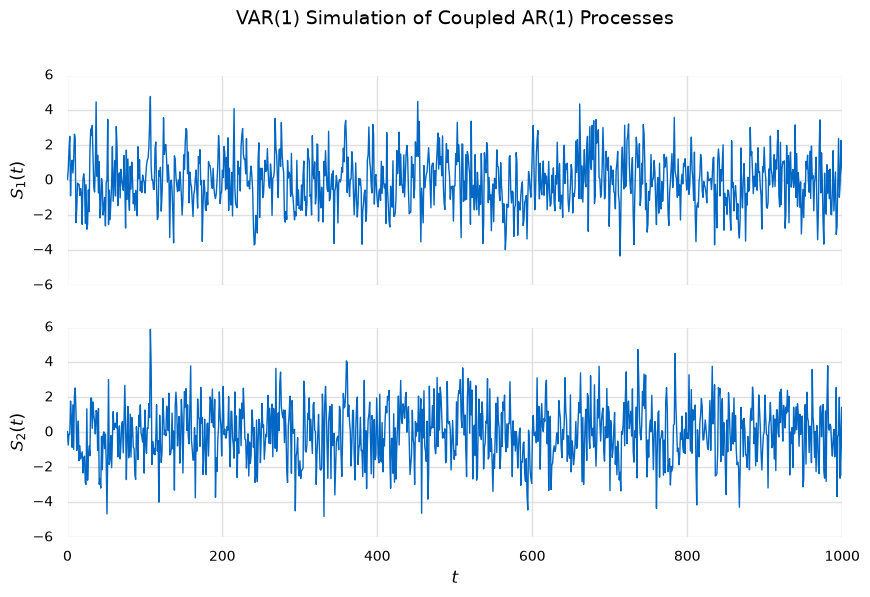

In [19]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [20]:
result, result_model = var.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.688,1.690,5.406,1.688
1,1.370*,1.378*,3.935*,1.373*
2,1.371,1.384,3.940,1.376
3,1.372,1.391,3.945,1.379
4,1.373,1.397,3.948,1.382


In [21]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
   "_VAROrderTestReport__order": {
      "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
      "order": {
         "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
         "label": "$\\varepsilon_{AIC}$",
         "value": 1.3698107817980645
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
      "order": {
         "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "64a49971-6c51-4974-9e64-4dae9e7bc344",
         

In [22]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.37735
Nobs:                     4999.00    HQIC:                   1.37227
Log likelihood:          -17603.7    FPE:                    3.93351
AIC:                      1.36953    Det(Omega_mle):         3.92879
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.007592         0.019922           -0.381           0.703
L1.y1         0.268849         0.013882           19.367           0.000
L1.y2         0.050756         0.012595            4.030           0.000

Results for equation 

In [23]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.007592076500250899,
         "err": 0.019921791213052892,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "67f674b4-4c65-483f-a38e-d66fe0f8e874",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.017300622584481555,
         "err": 0.01998640675212712,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "67f674b4-4c65-483f-a38e-d66fe0f8e874",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 1,
   "params": [
      {
         "est": 0.2688485087607713,
         "err": 0.013881639933798255,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "67f674b4-4c65-483f-a38e-d66fe0f8e874

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [24]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [25]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

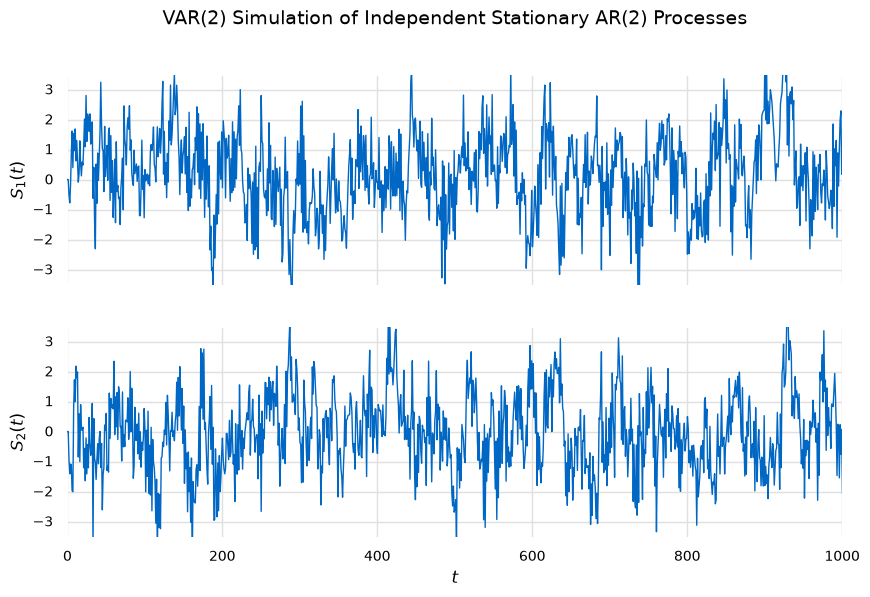

In [26]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [27]:
result, result_model = var.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.115,1.118,3.050,1.116
1,0.5209,0.5287,1.683,0.5236
2,-0.06716*,-0.05412*,0.9350*,-0.06259*
3,-0.06620,-0.04793,0.9359,-0.05980
4,-0.06501,-0.04153,0.9371,-0.05678


In [28]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
   "_VAROrderTestReport__order": {
      "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
      "order": {
         "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.06716325423819619
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
      "order": {
         "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "e7f8417d-3868-4cad-861c-9da3b01da4d0",
       

In [29]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0542932
Nobs:                     4998.00    HQIC:                -0.0627620
Log likelihood:          -14005.4    FPE:                   0.934885
AIC:                   -0.0673320    Det(Omega_mle):        0.933017
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.005556         0.014093           -0.394           0.693
L1.y1         0.241045         0.012138           19.859           0.000
L1.y2        -0.010040         0.012608           -0.796           0.426
L2.y1         0.514431

In [30]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.005556449631411899,
         "err": 0.014093041922511311,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "e7ad7e9f-92fe-4d10-a7e7-e800be399eb8",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.010929517951743743,
         "err": 0.013736551554342507,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "e7ad7e9f-92fe-4d10-a7e7-e800be399eb8",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 2,
   "params": [
      {
         "est": 0.2410450690500047,
         "err": 0.012137740272581394,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e7ad7e9f-92fe-4d10-a7e7-e800be399eb8

### Coupled $\text{AR}(2)$

In [31]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [32]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

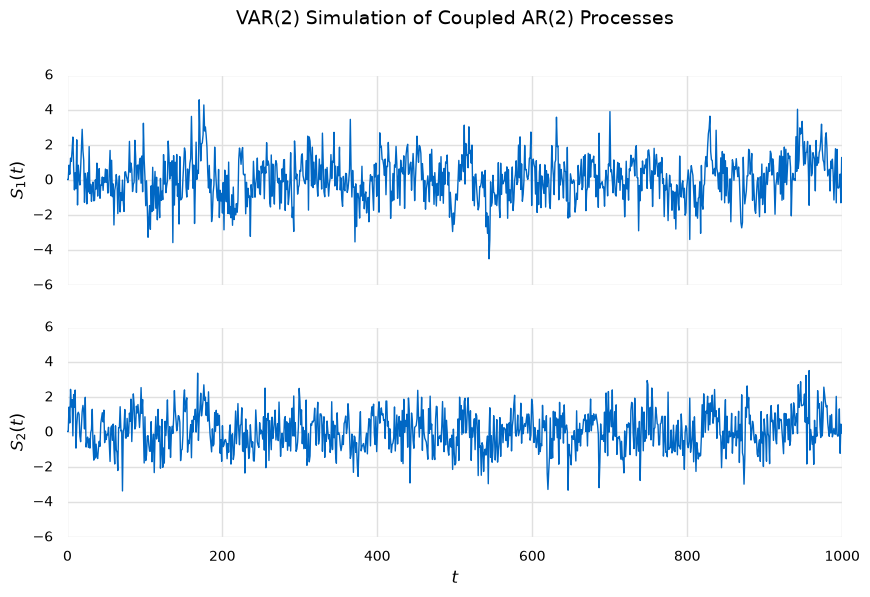

In [33]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [34]:
result, result_model = var.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4936,0.4962,1.638,0.4945
1,0.2558,0.2636,1.291,0.2585
2,0.004708*,0.01775*,1.005*,0.009280*
3,0.005520,0.02378,1.006,0.01192
4,0.005547,0.02903,1.006,0.01378


In [35]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
   "_VAROrderTestReport__order": {
      "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
      "order": {
         "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.004708340056181449
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
      "order": {
         "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "58c28c4b-f7cd-4a34-9cb0-9f2fd6c3b4b5",
       

In [36]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:01
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0174884
Nobs:                     4998.00    HQIC:                0.00901957
Log likelihood:          -14184.8    FPE:                    1.00446
AIC:                   0.00444958    Det(Omega_mle):         1.00245
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.007602         0.014334            0.530           0.596
L1.y1         0.134560         0.012962           10.381           0.000
L1.y2         0.143330         0.014024           10.220           0.000
L2.y1         0.249568

In [37]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": 0.007601964906783617,
         "err": 0.014333864563644348,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "1a0c0400-3e78-43cb-a9e1-10dc5ee9a8ee",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.006693732759992392,
         "err": 0.013989897696212256,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "1a0c0400-3e78-43cb-a9e1-10dc5ee9a8ee",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 2,
   "params": [
      {
         "est": 0.1345596919437515,
         "err": 0.012961954345786994,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "1a0c0400-3e78-43cb-a9e1-10dc5ee9a8ee"

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [38]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [39]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

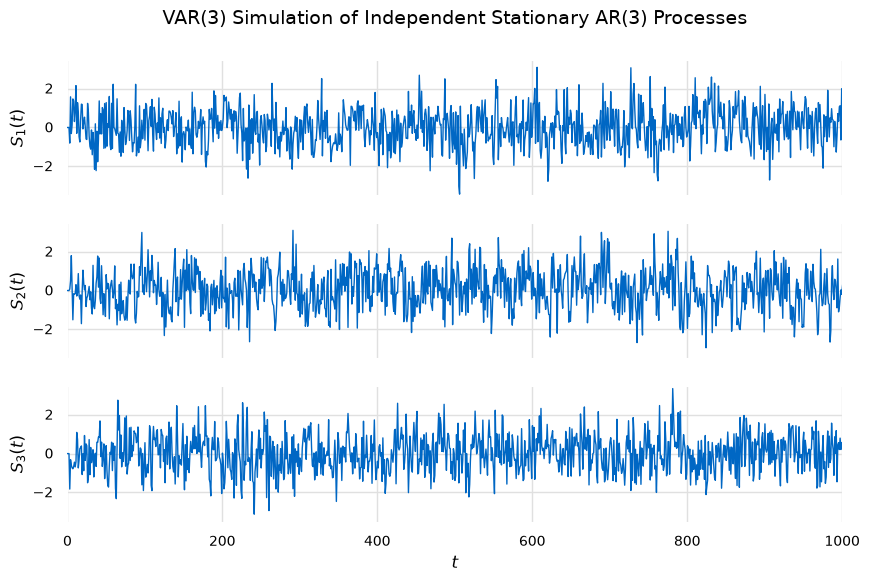

In [40]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [41]:
result, result_model = var.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1230,0.1269,1.131,0.1244
1,0.04719,0.06285,1.048,0.05268
2,0.03015,0.05754,1.031,0.03975
3,-0.01475*,0.02438*,0.9854*,-0.001039*
4,-0.01408,0.03679,0.9860,0.003750


In [42]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
   "_VAROrderTestReport__order": {
      "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
      "order": {
         "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.014753977816178595
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
      "order": {
         "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
         "label": "$\\tau_{BIC}$",
         "value": 3
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "9b2302e0-6f81-46fc-b77c-9b77b746f6c9",
      

In [43]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:01
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0245954
Nobs:                     4997.00    HQIC:              -0.000815190
Log likelihood:          -21205.0    FPE:                   0.985577
AIC:                   -0.0145276    Det(Omega_mle):        0.979684
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.009351         0.014084            0.664           0.507
L1.y1         0.148190         0.013985           10.596           0.000
L1.y2        -0.018647         0.013892           -1.342           0.180
L1.y3        -0.002120

In [44]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": 0.009350803975941176,
         "err": 0.01408406057129603,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "d52a8f9a-9d73-4793-9aa5-f8db7db1e253",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.012273231317786692,
         "err": 0.01420827927314709,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "d52a8f9a-9d73-4793-9aa5-f8db7db1e253",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.0011980473190202773,
         "err": 0.014033703582155206,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "d52a8f9a-9d73-4793-9aa5-f8db7db1e253",
         "param_type": "VAR_CONST"
     

### Coupled $\text{AR}(3)$

In [45]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=3
var.compute_is_stationary(phi)


True

In [46]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

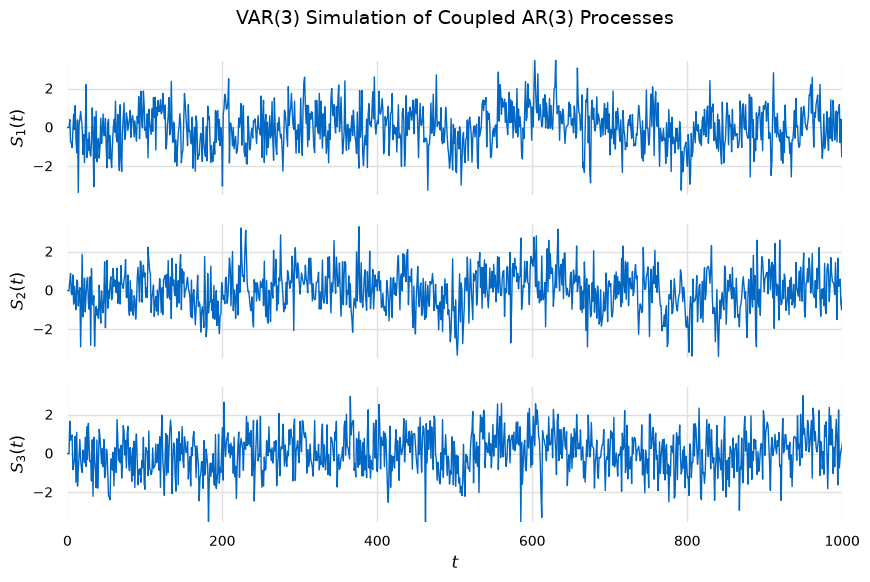

In [47]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [48]:
result, result_model = var.compute_lag_order(xt, maxlags=5)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3983,0.4022,1.489,0.3997
1,0.1636,0.1792,1.178,0.1691
2,0.08794,0.1153,1.092,0.09754
3,0.003975*,0.04311*,1.004*,0.01769*
4,0.006877,0.05775,1.007,0.02471
5,0.008785,0.07140,1.009,0.03073


In [49]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
   "_VAROrderTestReport__order": {
      "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
      "order": {
         "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.003974731829665196
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
      "order": {
         "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
         "label": "$\\tau_{BIC}$",
         "value": 3
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "26dabd66-62d1-47fe-b5a3-e49018957651",
       

In [50]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     18:32:01
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0429622
Nobs:                     4997.00    HQIC:                 0.0175516
Log likelihood:          -21250.9    FPE:                    1.00385
AIC:                   0.00383913    Det(Omega_mle):        0.997844
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.013285         0.014132           -0.940           0.347
L1.y1         0.155741         0.013904           11.201           0.000
L1.y2         0.101119         0.013961            7.243           0.000
L1.y3         0.211376

In [51]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.013284533283655434,
         "err": 0.014132217636133487,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "95f3e921-ac5c-4579-b34d-e9920ba86bca",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.025832535188817306,
         "err": 0.01414968311602871,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "95f3e921-ac5c-4579-b34d-e9920ba86bca",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.005198956674512359,
         "err": 0.014284179846328002,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "95f3e921-ac5c-4579-b34d-e9920ba86bca",
         "param_type": "VAR_CONST"
   